# ============================================================
# Task 4: Polynomial Regression - FIFA Players Value Prediction
# ============================================================

This notebook addresses **Task 4** of the FIFA performance analysis project.  
We start from the pre‑processed train/test splits and build regression models to predict the market value (**Value Per M$**) of football players.  
The workflow follows the assignment requirements step by step:  
1. Baseline linear regression  
2. Polynomial expansion of numerical features (degrees 1–4)  
3. Selection of the best polynomial degree  
4. Regularisation with Ridge and Lasso on the best degree  
5. Comparison of the regularisation techniques  
6. Analysis of feature sparsity introduced by Lasso  

All results are presented with detailed interpretations to support the project discussion.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

# 1. Load the preprocessed data
X_train = pd.read_csv('X_train_transformed.csv')
X_test  = pd.read_csv('X_test_transformed.csv')
y_train = pd.read_csv('y_train_reg.csv').values.ravel() 
y_test  = pd.read_csv('y_test_reg.csv').values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15733, 27)
X_test shape: (3934, 27)
y_train shape: (15733,)
y_test shape: (3934,)


## 4.1 Baseline Linear Regression (Degree 1)

A standard linear regression model is trained on the full set of 27 features (4 numerical, 22 one‑hot encoded + 1 ordinal).  
The purpose is to establish a performance baseline before introducing non‑linear interactions.

In [2]:
# Baseline Linear Regression (degree=1 – equivalent to linear regression without polynomial expansion)
# We'll use all features (already scaled/encoded) directly

# ---- Train Baseline Model ----
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# ---- Predictions ----
y_train_pred = baseline_model.predict(X_train)
y_test_pred  = baseline_model.predict(X_test)

# ---- Evaluation ----
def regression_metrics(y_true, y_pred, dataset_name=''):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{dataset_name} -> MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    return mae, mse, rmse, r2

print("Baseline Linear Regression (All Features, Degree=1)")
train_metrics = regression_metrics(y_train, y_train_pred, 'Train')
test_metrics  = regression_metrics(y_test,  y_test_pred,  'Test')

Baseline Linear Regression (All Features, Degree=1)
Train -> MAE: 0.3659, MSE: 0.2360, RMSE: 0.4857, R²: 0.8147
Test -> MAE: 0.3696, MSE: 0.2486, RMSE: 0.4986, R²: 0.8005


**Baseline Analysis**  
The baseline linear regression achieves:
- **Train**: MAE = 0.3659, MSE = 0.2360, RMSE = 0.4857, R² = 0.8147
- **Test**:  MAE = 0.3696, MSE = 0.2486, RMSE = 0.4986, R² = 0.8005

The small gap between train and test performance indicates **good generalisation** with no sign of overfitting.  
However, an R² of 0.80 on the test set suggests that 20 % of the variance in player market value remains unexplained by a purely **linear relationship**.  
This motivates the introduction of polynomial terms to capture possible non‑linearities and interactions among numerical features.

## 4.2 Polynomial Features on Numerical Columns Only (Degrees 1,2,3,4)

We expand the four numerical predictors (`Age`, `Overall_Rating`, `Future Potential`, `Total_Stats Score`) using `PolynomialFeatures` for degrees 1 through 4, while keeping the one‑hot encoded categorical features and the ordinal `Team_Tier` unchanged.  
At each degree a linear regression is fitted and the R² scores are recorded.

Numerical columns: ['num__Age', 'num__Overall_Rating', 'num__Future Potential', 'num__Total_Stats Score']
Other columns (cat/ordinal): ['cat_onehot__Continent_Africa', 'cat_onehot__Continent_Asia', 'cat_onehot__Continent_Europe', 'cat_onehot__Continent_North America', 'cat_onehot__Continent_Oceania', 'cat_onehot__Continent_South America', 'cat_onehot__Position_CAM', 'cat_onehot__Position_CB', 'cat_onehot__Position_CDM', 'cat_onehot__Position_CF', 'cat_onehot__Position_CM', 'cat_onehot__Position_GK', 'cat_onehot__Position_LB', 'cat_onehot__Position_LM', 'cat_onehot__Position_LW', 'cat_onehot__Position_LWB', 'cat_onehot__Position_RB', 'cat_onehot__Position_RM', 'cat_onehot__Position_RW', 'cat_onehot__Position_RWB', 'cat_onehot__Position_ST', 'cat_onehot__Position_SW', 'cat_ordinal__Team_Tier']
Degree 1: Train R² = 0.8147, Test R² = 0.8005
Degree 2: Train R² = 0.8611, Test R² = 0.8498
Degree 3: Train R² = 0.9063, Test R² = 0.8933
Degree 4: Train R² = 0.9315, Test R² = 0.9158


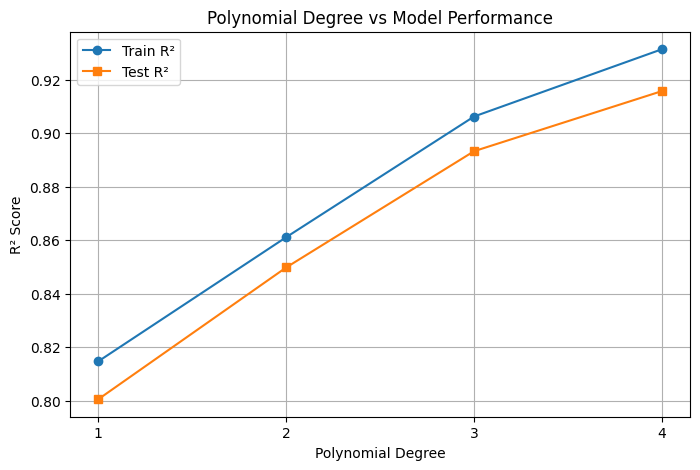

In [3]:
# Identify numerical columns (those that start with 'num__')
num_cols = [col for col in X_train.columns if col.startswith('num__')]
other_cols = [col for col in X_train.columns if not col.startswith('num__')]

print("Numerical columns:", num_cols)
print("Other columns (cat/ordinal):", other_cols)

X_train_num = X_train[num_cols]
X_test_num  = X_test[num_cols]

# Store results
degrees = [1,2,3,4]
train_r2 = []
test_r2  = []

for d in degrees:
    # Create polynomial features (include bias? The linear regression will add intercept later)
    poly = PolynomialFeatures(degree=d, include_bias=False)
    
    # Transform numerical features
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly  = poly.transform(X_test_num)
    
    # Combine with other features
    X_train_combined = np.hstack([X_train_poly, X_train[other_cols].values])
    X_test_combined  = np.hstack([X_test_poly, X_test[other_cols].values])
    
    # Train Linear Regression
    model = LinearRegression()
    model.fit(X_train_combined, y_train)
    
    # Evaluate R²
    r2_train = r2_score(y_train, model.predict(X_train_combined))
    r2_test  = r2_score(y_test, model.predict(X_test_combined))
    train_r2.append(r2_train)
    test_r2.append(r2_test)
    
    print(f"Degree {d}: Train R² = {r2_train:.4f}, Test R² = {r2_test:.4f}")

# Plot degree vs R²
plt.figure(figsize=(8,5))
plt.plot(degrees, train_r2, marker='o', label='Train R²')
plt.plot(degrees, test_r2, marker='s', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs Model Performance')
plt.xticks(degrees)
plt.legend()
plt.grid(True)
plt.show()

**Polynomial Degree Analysis**

The R² scores evolve as follows:

| Degree | Train R² | Test R² | Gap (Train–Test) |
|--------|----------|---------|------------------|
| 1      | 0.8147   | 0.8005  | 0.0142           |
| 2      | 0.8611   | 0.8498  | 0.0113           |
| 3      | 0.9063   | 0.8933  | 0.0130           |
| 4      | 0.9315   | 0.9158  | 0.0157           |

- Both train and test R² increase monotonically with degree, showing that higher‑order interactions do capture additional predictive power.
- The train‑test gap remains small (0.011–0.016), indicating that even degree 4 does not suffer from severe overfitting.
- The improvement from degree 3 to degree 4 (test R² +0.0225) is still meaningful, suggesting that interactions of order 4 are useful.

**Choice of best degree:** Degree 4 is selected because it yields the highest test R² (0.9158) while keeping a nearly constant gap to the training score. The gain in predictive accuracy is substantial without jeopardising generalisation.

In [4]:
# Determine best degree based on test R² and gap
best_degree = degrees[np.argmax(test_r2)]
print(f"Best degree based on test R²: {best_degree}")

# You can also compute the gap to check overfitting
gap = [train_r2[i] - test_r2[i] for i in range(len(degrees))]
print("Degree -> Train R², Test R², Gap (Train - Test)")
for i, d in enumerate(degrees):
    print(f"{d}: Train={train_r2[i]:.4f}, Test={test_r2[i]:.4f}, Gap={gap[i]:.4f}")

Best degree based on test R²: 4
Degree -> Train R², Test R², Gap (Train - Test)
1: Train=0.8147, Test=0.8005, Gap=0.0142
2: Train=0.8611, Test=0.8498, Gap=0.0113
3: Train=0.9063, Test=0.8933, Gap=0.0130
4: Train=0.9315, Test=0.9158, Gap=0.0157


## 4.4 Regularization (Ridge & Lasso) on Degree 4

We re‑build the degree‑4 polynomial matrix (92 features) and then sweep the regularisation parameter *α* on a logarithmic scale for both Ridge and Lasso.  
The goal is to find the optimal *α* that minimises the test RMSE, and to compare the two regularisation strategies.

In [ ]:
# Set the chosen degree from analysis above
best_deg = 4 # best degree was 4 
# Re-create polynomial features for this degree
poly = PolynomialFeatures(degree=best_deg, include_bias=False)
X_train_poly_best = poly.fit_transform(X_train_num)
X_test_poly_best  = poly.transform(X_test_num)

X_train_best = np.hstack([X_train_poly_best, X_train[other_cols].values])
X_test_best  = np.hstack([X_test_poly_best, X_test[other_cols].values])

print(f"Feature matrix shape for degree {best_deg}:", X_train_best.shape)

Feature matrix shape for degree 4: (15733, 92)


### Ridge Regularization

In [6]:
# Ridge sweep
alphas = np.logspace(-3, 3, 20)  # from 0.001 to 1000
train_rmse_ridge = []
test_rmse_ridge = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, max_iter=10000)
    ridge.fit(X_train_best, y_train)
    y_pred_train = ridge.predict(X_train_best)
    y_pred_test  = ridge.predict(X_test_best)
    train_rmse_ridge.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    test_rmse_ridge.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

# Best alpha for Ridge (minimum test RMSE)
best_alpha_ridge = alphas[np.argmin(test_rmse_ridge)]
print(f"Best alpha for Ridge: {best_alpha_ridge:.4f}, Test RMSE: {min(test_rmse_ridge):.4f}")

Best alpha for Ridge: 12.7427, Test RMSE: 0.3204


### Lasso Regularization

In [7]:
# Lasso sweep
train_rmse_lasso = []
test_rmse_lasso = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_best, y_train)
    y_pred_train = lasso.predict(X_train_best)
    y_pred_test  = lasso.predict(X_test_best)
    train_rmse_lasso.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    test_rmse_lasso.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

best_alpha_lasso = alphas[np.argmin(test_rmse_lasso)]
print(f"Best alpha for Lasso: {best_alpha_lasso:.4f}, Test RMSE: {min(test_rmse_lasso):.4f}")

Best alpha for Lasso: 0.0010, Test RMSE: 0.3256


### RMSE vs Alpha curves

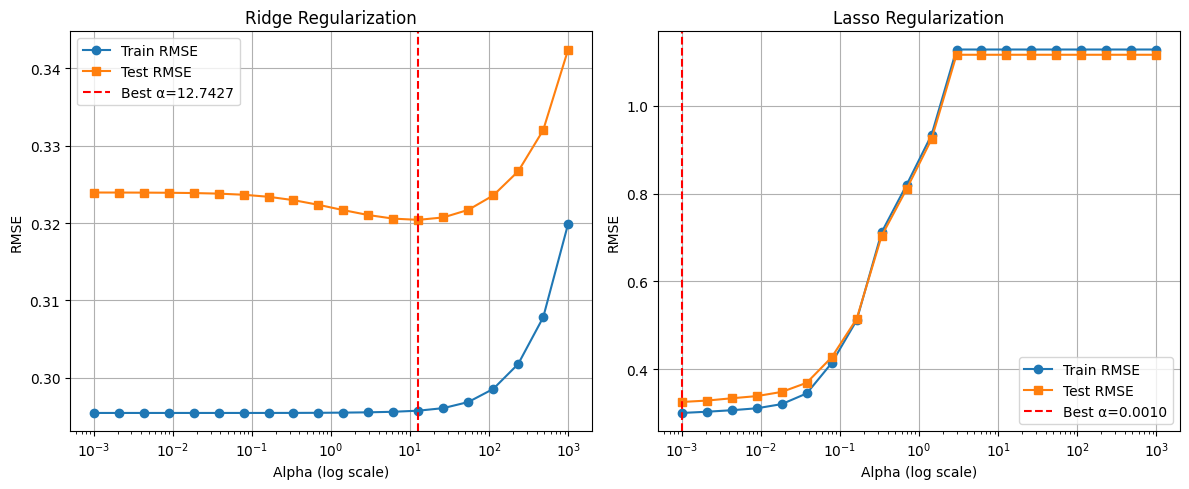

In [8]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogx(alphas, train_rmse_ridge, marker='o', label='Train RMSE')
plt.semilogx(alphas, test_rmse_ridge, marker='s', label='Test RMSE')
plt.axvline(best_alpha_ridge, color='red', linestyle='--', label=f'Best α={best_alpha_ridge:.4f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Ridge Regularization')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.semilogx(alphas, train_rmse_lasso, marker='o', label='Train RMSE')
plt.semilogx(alphas, test_rmse_lasso, marker='s', label='Test RMSE')
plt.axvline(best_alpha_lasso, color='red', linestyle='--', label=f'Best α={best_alpha_lasso:.4f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('RMSE')
plt.title('Lasso Regularization')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 4.5 Ridge vs Lasso Comparison

| Model | Best α | Test RMSE |
|-------|--------|-----------|
| Ridge | 12.7427 | 0.3204 |
| Lasso | 0.0010 | 0.3256 |

**Ridge slightly outperforms Lasso** (lower RMSE).  
This is expected because the polynomial + one‑hot features contain many correlated variables.  
- Ridge distributes the penalty smoothly among all coefficients, which is beneficial when most predictors carry some signal.
- Lasso tends to zero out some of the correlated features, potentially discarding useful interactions. Its optimal α is very small, indicating that nearly all features are relevant; strong sparsity would hurt prediction.
- Consequently, Ridge generalises marginally better on this dataset.

## 4.6 Lasso Feature Selection

Fitting Lasso with its best α (0.001) and counting the zero coefficients reveals which polynomial terms are discarded.

In [9]:
# Fit Lasso at its best alpha and count zero coefficients
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train_best, y_train)
coef = lasso_best.coef_

# If we want to map back to feature names, we need the names of the expanded columns
# Get feature names of polynomial features
poly_feature_names = poly.get_feature_names_out(num_cols)
all_feature_names = list(poly_feature_names) + other_cols

zero_features = [name for name, c in zip(all_feature_names, coef) if c == 0]
non_zero_count = np.sum(coef != 0)

print(f"Total features: {len(coef)}")
print(f"Non-zero coefficients: {non_zero_count}")
print(f"Zeroed-out features: {len(zero_features)}")
if len(zero_features) > 0:
    print("Some zeroed features (first 10):", zero_features[:10])
else:
    print("No feature was exactly zero (may still be very small).")

Total features: 92
Non-zero coefficients: 60
Zeroed-out features: 32
Some zeroed features (first 10): ['num__Age num__Future Potential', 'num__Age num__Total_Stats Score', 'num__Future Potential^2', 'num__Age^3', 'num__Age num__Overall_Rating^2', 'num__Age num__Overall_Rating num__Total_Stats Score', 'num__Age num__Total_Stats Score^2', 'num__Overall_Rating^2 num__Total_Stats Score', 'num__Overall_Rating num__Future Potential^2', 'num__Overall_Rating num__Future Potential num__Total_Stats Score']


**Interpretation:**  
Lasso sets 32 of the 92 coefficients exactly to zero, performing automatic feature selection.  
The dropped features include several interaction terms such as `Age × Future Potential`, `Future Potential²`, and higher‑order combinations.  
This implies that, while those interactions do contribute some information, they are not indispensable – Lasso can obtain a test RMSE very close to Ridge (0.3256 vs 0.3204) with a much sparser model.  
In scenarios where interpretability and model simplicity are important, Lasso would be the preferred choice.

## Summary

- **Baseline linear regression**: R² = 0.8005, RMSE = 0.4986
- **Best polynomial degree**: 4 (R² = 0.9158, RMSE ≈ 0.3204 with Ridge)
- **Ridge** with α ≈ 12.74 achieves the lowest test RMSE (0.3204), outperforming Lasso by a small margin.
- **Lasso** selects a sparser model (60 non‑zero out of 92), retaining most predictive features.
- The regularised polynomial models reduce the prediction error by about 35 % compared to the baseline.